In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df=pd.read_csv("../data/covid_data.csv")
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,3.120880e+05,3.404570e+05,3.391980e+05,2.905010e+05,340511.000000,339281.000000,312088.000000,340457.000000,339198.000000,290501.000000,...,200889.000000,132973.000000,239669.000000,322072.000000,263138.000000,3.500850e+05,1.218400e+04,12184.000000,12184.000000,12184.000000
mean,6.683354e+06,9.601634e+03,9.637066e+03,8.602180e+04,85.511055,85.817071,101749.851259,145.163814,145.696924,872.289356,...,32.909483,50.789962,3.097245,73.713631,0.722464,1.284633e+08,5.281637e+04,9.738648,11.345256,1669.025575
std,4.068903e+07,1.102769e+05,9.447784e+04,4.398873e+05,613.687971,559.130004,151265.689121,1163.714678,599.957847,1100.189784,...,13.573767,31.956100,2.548327,7.395220,0.148976,6.607694e+08,1.492195e+05,12.304441,25.181297,1938.556228
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2752.924800
25%,8.090000e+03,0.000000e+00,2.860000e-01,1.270000e+02,0.000000,0.000000,2595.577500,0.000000,0.044000,60.606000,...,22.600000,20.859000,1.300000,69.590000,0.602000,4.490020e+05,1.202250e+02,1.400000,-1.600000,72.395046
50%,7.020500e+04,2.000000e+00,2.485700e+01,1.328000e+03,0.000000,0.143000,28307.659000,0.128000,6.517000,377.169000,...,33.100000,49.839000,2.500000,75.050000,0.740000,5.882259e+06,5.885850e+03,8.075000,5.720000,1105.404700
75%,7.409558e+05,2.640000e+02,4.978570e+02,1.192200e+04,3.000000,5.143000,133506.244000,35.466000,82.411000,1365.925000,...,41.300000,82.502000,4.200000,79.460000,0.829000,2.830170e+07,3.742344e+04,15.360000,16.302500,2740.130200
max,7.714071e+08,8.401961e+06,6.402036e+06,6.972139e+06,27939.000000,14822.000000,737554.506000,228872.025000,37241.781000,6511.209000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.289776e+06,76.620000,377.630000,10292.916000


In [4]:
df.isnull().sum()

iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64

In [5]:
df.fillna(0 , inplace=True)

In [6]:
df['date'] = pd.to_datetime(df['date'])


In [18]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    350085 non-null  object        
 1   continent                                   350085 non-null  object        
 2   location                                    350085 non-null  object        
 3   date                                        350085 non-null  datetime64[ns]
 4   total_cases                                 350085 non-null  float64       
 5   new_cases                                   350085 non-null  float64       
 6   new_cases_smoothed                          350085 non-null  float64       
 7   total_deaths                                350085 non-null  float64       
 8   new_deaths                                  350085 non-null  float64      

In [9]:
df['location'].nunique()
df['location'].unique()[:10]

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina'], dtype=object)

In [10]:
df[['total_cases', 'total_deaths']].describe()


,total_cases,total_deaths
count,3.500850e+05,3.500850e+05
mean,5.957966e+06,7.138101e+04
std,3.847370e+07,4.020102e+05
min,0.000000e+00,0.000000e+00
25%,2.478000e+03,1.900000e+01
50%,4.126700e+04,4.940000e+02
75%,5.568890e+05,7.688000e+03
max,7.714071e+08,6.972139e+06


In [11]:
country_summary = df.groupby('location')[['total_cases', 'total_deaths']].max().reset_index()
country_summary.sort_values('total_cases', ascending=False).head(10)


,location,total_cases,total_deaths
251,World,771407061.0,6972139.0
96,High income,425988398.0,2914272.0
12,Asia,300681974.0,1633880.0
70,Europe,249783754.0,2079783.0
241,Upper middle income,244463792.0,2666760.0
71,European Union,184210531.0,1245398.0
162,North America,124492151.0,1613118.0
239,United States,103436829.0,1136920.0
44,China,99315684.0,121742.0
128,Lower middle income,97458491.0,1339160.0


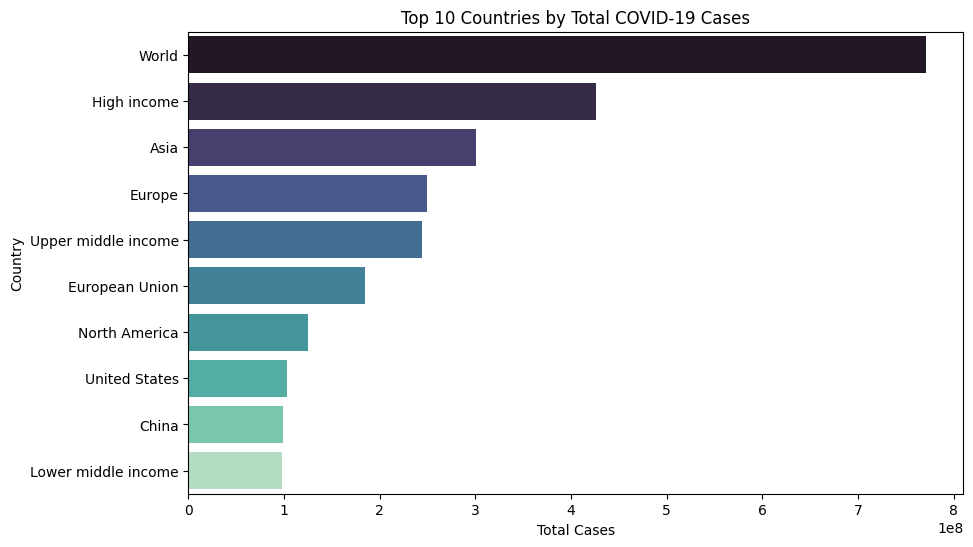

In [12]:

top10 = country_summary.nlargest(10, 'total_cases')
plt.figure(figsize=(10, 6))
sns.barplot(x='total_cases', y='location', hue='location', data=top10, palette='mako', legend=False)
plt.title('Top 10 Countries by Total COVID-19 Cases')
plt.xlabel('Total Cases')
plt.ylabel('Country')

plt.savefig(r"D:\My_Project\Analyse\COVID19_EDA\figures\Top_10_Countries_by_Total_COVID19_Cases.png")
plt.show()



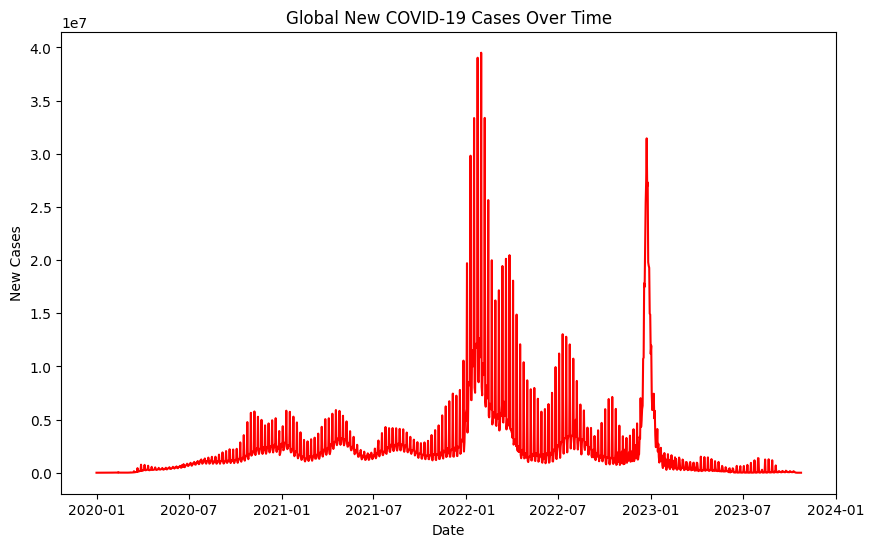

In [13]:
global_trend = df.groupby('date')['new_cases'].sum().reset_index()
plt.figure(figsize=(10,6))
plt.plot(global_trend['date'], global_trend['new_cases'], color='red')
plt.title('Global New COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.savefig(r"D:\My_Project\Analyse\COVID19_EDA\figures\Global New COVID-19 Cases Over Time.png")
plt.show()


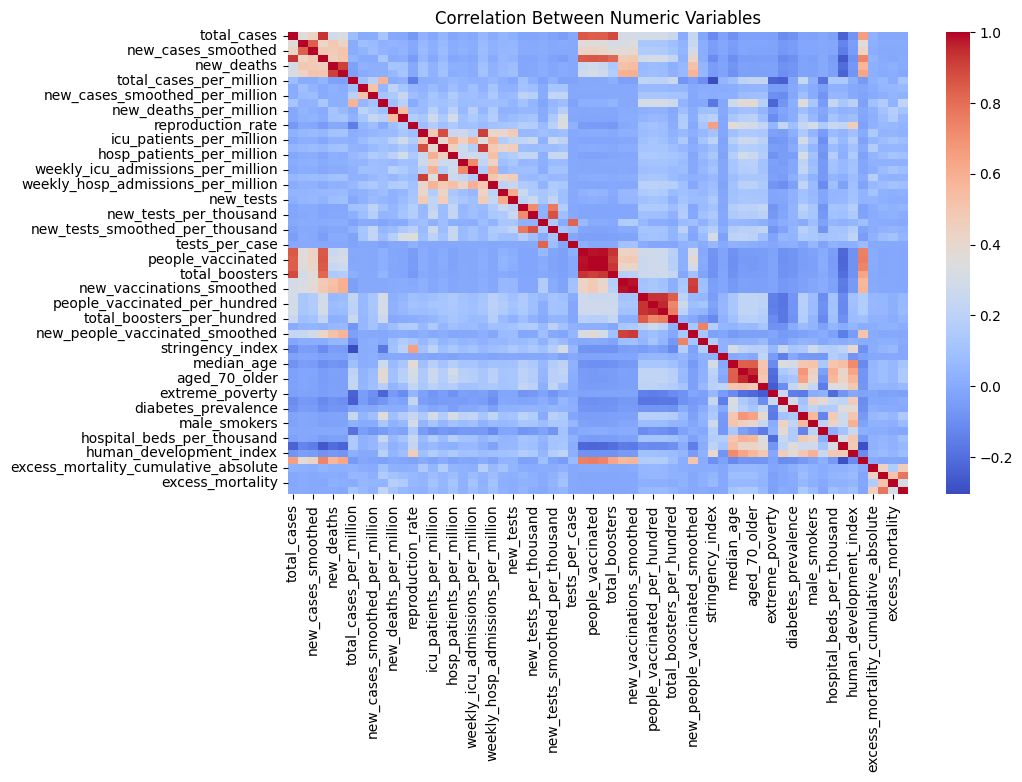

In [14]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Between Numeric Variables')

plt.savefig(r"D:\My_Project\Analyse\COVID19_EDA\figures\Correlation Between Numeric Variables.png")
plt.show()


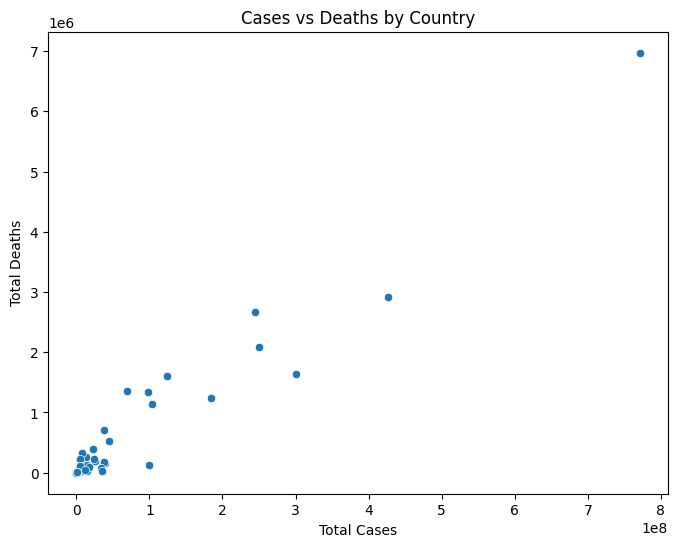

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_cases', y='total_deaths', data=country_summary)
plt.title('Cases vs Deaths by Country')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')

plt.savefig(r"D:\My_Project\Analyse\COVID19_EDA\figures\Cases vs Deaths by Country.png")
plt.show()


In [16]:
fig = px.choropleth(
    country_summary,
    locations='location',
    locationmode='country names',
    color='total_cases',
    hover_name='location',
    title='COVID-19 Total Cases Worldwide',
    color_continuous_scale='reds'
)

plt.savefig(r"D:\My_Project\Analyse\COVID19_EDA\figures\COVID-19 Total Cases Worldwide.png")

fig.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13708\1333663034.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


<Figure size 640x480 with 0 Axes>

In [17]:
df.to_csv(r"D:\My_Project\Analyse\COVID19_EDA\data\cleaned_covid19_data.csv", index=False)

